## Linear Regression Model Comparison

This script generates synthetic data with outliers and fits six different regression models
to compare their behavior:
- OLS (Ordinary Least Squares)
- LAD (Least Absolute Deviations)
- Huber
- Ridge
- Lasso
- Bayesian

### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import (
    LinearRegression,  # OLS
    QuantileRegressor,  # Used for LAD
    HuberRegressor,
    Ridge,
    Lasso,
    BayesianRidge,
)

### Data Generation

In [2]:
np.random.seed(42)

# Generates 50 data points with a linear trend
n_samples = 50
X = np.sort(np.random.rand(n_samples) * 20).reshape(-1, 1)
y_true = 2.5 * X.ravel() + 10  # True linear relationship
y = y_true + np.random.normal(0, 5, n_samples)  # Add Gaussian noise

# Add outliers to test the robustness of the models
n_outliers = 5
outlier_indices = np.random.choice(np.arange(n_samples), n_outliers, replace=False)
y[outlier_indices] = y[outlier_indices] + np.random.uniform(-80, 80, n_outliers)

### Model Definition and Training

In [3]:
models = {
    "OLS": LinearRegression(),
    # LAD (L1 Loss) is equivalent to Quantile Regression on the median (quantile=0.5)
    "LAD (L1 Loss)": QuantileRegressor(quantile=0.5, alpha=0, solver="highs"),
    "Huber": HuberRegressor(),
    # Regularized models (alpha is the regularization parameter)
    "Ridge (L2)": Ridge(alpha=1.0),
    "Lasso (L1)": Lasso(alpha=0.5),
    "Bayesian": BayesianRidge(),
}

# Train each model and store the results
predictions = {}
coefficients = {}

print("Coefficients (Slope) found by each model:")
print("-" * 50)
for name, model in models.items():
    model.fit(X, y)
    predictions[name] = model.predict(X)
    # Stores the slope (slope)
    if hasattr(model, "coef_"):
        coefficients[name] = model.coef_[0]
        print(f"{name:<15}: {model.coef_[0]:.4f}")
print("-" * 50)

Coefficients (Slope) found by each model:
--------------------------------------------------
OLS            : 2.4156
LAD (L1 Loss)  : 2.5163
Huber          : 2.5091
Ridge (L2)     : 2.4142
Lasso (L1)     : 2.4004
Bayesian       : 2.3634
--------------------------------------------------


### Plots

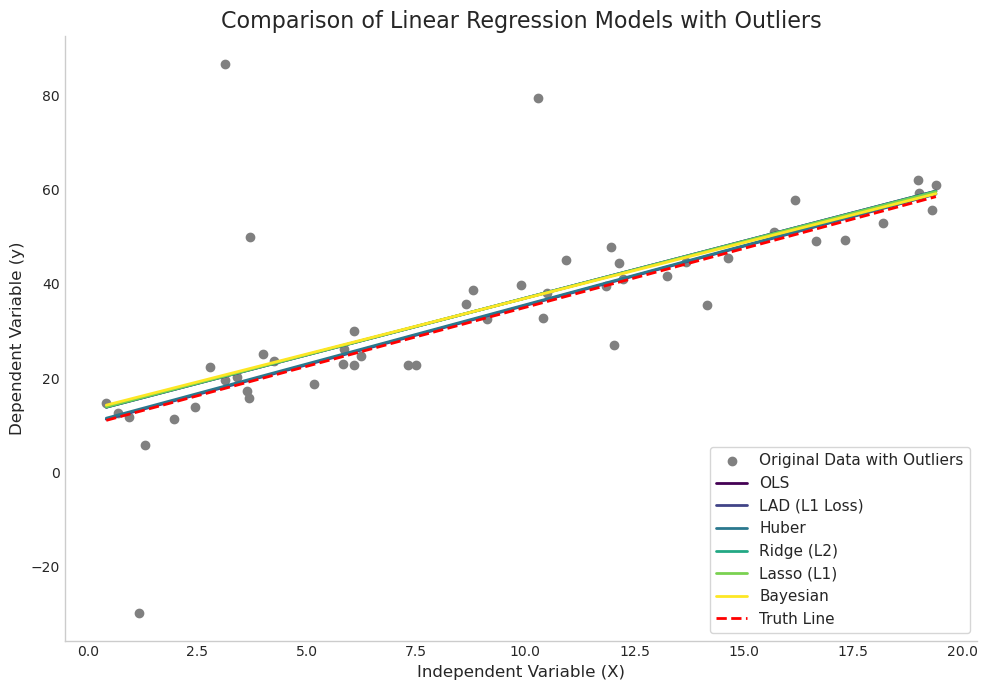

In [4]:
plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(10, 7))

# Plot the original data (including outliers)
plt.scatter(X, y, color="gray", marker="o", label="Original Data with Outliers")

# Plot the regression line for each model
colors = plt.cm.viridis(np.linspace(0, 1, len(models)))
for i, (name, y_pred) in enumerate(predictions.items()):
    plt.plot(X, y_pred, color=colors[i], linestyle="-", linewidth=2, label=f"{name}")

# Plot the true line (no noise and no outliers) for reference
plt.plot(
    X,
    y_true,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Truth Line",
)

# Chart Settings
plt.title("Comparison of Linear Regression Models with Outliers", fontsize=16)
plt.xlabel("Independent Variable (X)", fontsize=12)
plt.ylabel("Dependent Variable (y)", fontsize=12)
plt.legend(frameon=True, fontsize=11)
plt.grid(False)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()